#Lab 5

Using device: cuda


100%|██████████| 170M/170M [00:04<00:00, 39.2MB/s]


Starting Training...
Epoch [1/30], Loss: 0.0523
Epoch [2/30], Loss: 0.0217
Epoch [3/30], Loss: 0.0176
Epoch [4/30], Loss: 0.0158
Epoch [5/30], Loss: 0.0147
Epoch [6/30], Loss: 0.0140
Epoch [7/30], Loss: 0.0134
Epoch [8/30], Loss: 0.0130
Epoch [9/30], Loss: 0.0127
Epoch [10/30], Loss: 0.0125
Epoch [11/30], Loss: 0.0124
Epoch [12/30], Loss: 0.0122
Epoch [13/30], Loss: 0.0121
Epoch [14/30], Loss: 0.0120
Epoch [15/30], Loss: 0.0119
Epoch [16/30], Loss: 0.0119
Epoch [17/30], Loss: 0.0118
Epoch [18/30], Loss: 0.0117
Epoch [19/30], Loss: 0.0117
Epoch [20/30], Loss: 0.0116
Epoch [21/30], Loss: 0.0116
Epoch [22/30], Loss: 0.0115
Epoch [23/30], Loss: 0.0115
Epoch [24/30], Loss: 0.0115
Epoch [25/30], Loss: 0.0114
Epoch [26/30], Loss: 0.0114
Epoch [27/30], Loss: 0.0114
Epoch [28/30], Loss: 0.0114
Epoch [29/30], Loss: 0.0113
Epoch [30/30], Loss: 0.0113
Training Finished.


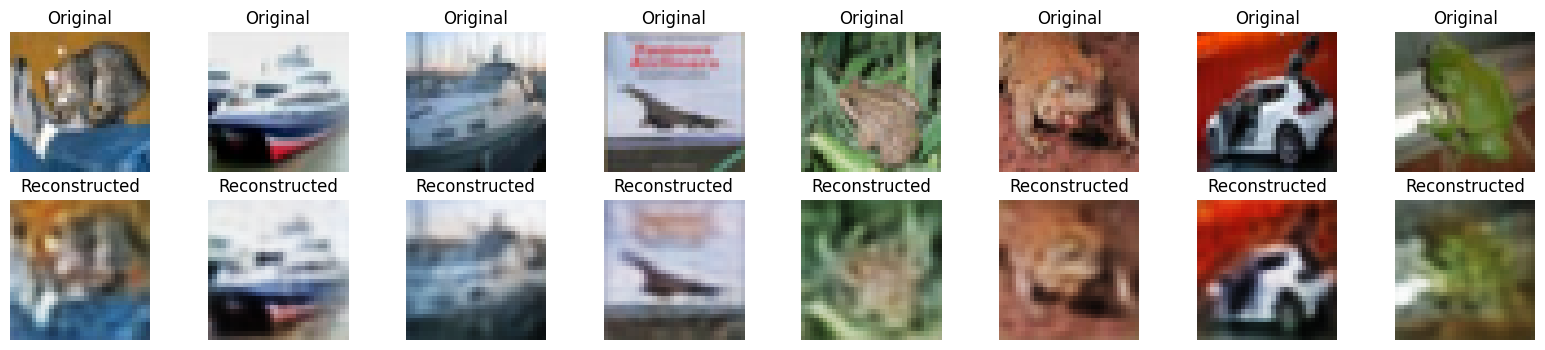

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 30

print(f"Using device: {DEVICE}")


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=10,
                                         shuffle=False, num_workers=2)


class EncoderDecoder(nn.Module):
    def __init__(self):
        super(EncoderDecoder, self).__init__()


        # Input: 3 x 32 x 32
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2, padding=1),  # -> 16 x 16 x 16
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), # -> 32 x 8 x 8
            nn.ReLU(),
            nn.Conv2d(32, 64, 7) # -> 64 x 2 x 2 (Bottleneck)
        )


        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 7), # -> 32 x 8 x 8
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), # -> 16 x 16 x 16
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, 3, stride=2, padding=1, output_padding=1), # -> 3 x 32 x 32
            nn.Tanh() # Output activation to map back to [-1, 1]
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

model = EncoderDecoder().to(DEVICE)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)


print("Starting Training...")
loss_history = []

for epoch in range(EPOCHS):
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # We use the image as both input and target (Reconstruction)
        inputs, _ = data
        inputs = inputs.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, inputs) # MSE Loss

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(trainloader)
    loss_history.append(avg_loss)
    print(f'Epoch [{epoch+1}/{EPOCHS}], Loss: {avg_loss:.4f}')

print("Training Finished.")


def imshow(img, title):
   #[-1,1] to [0,1]
    img = img / 2 + 0.5
    npimg = img.cpu().numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(title)
    plt.axis('off')


dataiter = iter(testloader)
images, _ = next(dataiter)
images = images.to(DEVICE)

# reconstructions
with torch.no_grad():
    outputs = model(images)


plt.figure(figsize=(20, 4))
num_images = 8

for i in range(num_images):
    # Original
    ax = plt.subplot(2, num_images, i + 1)
    imshow(images[i].cpu(), "Original")

    # Reconstructed
    ax = plt.subplot(2, num_images, i + 1 + num_images)
    imshow(outputs[i].cpu(), "Reconstructed")

plt.show()